# 02 - Análisis de sentimiento

> **Objetivo final del sistema:** Diseñar un agente basado en LLM capaz de recibir quejas 
> ciudadanas en texto (y opcionalmente imagen), clasificar la temática, estimar el nivel de 
> urgencia a partir del contenido y el sentimiento, y mantener una conversación orientada a 
> la gestión de la incidencia.

---

## Contexto de este notebook

El notebook anterior (`01_clasificacion_tematica`) produjo un dataset enriquecido con la 
categoría temática de cada propuesta (NMF y LDA). Este notebook añade una segunda capa de 
información: la **señal emocional**.

El análisis de sentimiento se aplica sobre las quejas ciudadanas con dos objetivos concretos:

- **Polaridad** → clasificar cada queja como negativa, neutra o positiva
- **Intensidad de malestar** → obtener una variable continua y discreta que permita 
estimar la urgencia de la incidencia

Estas señales alimentarán directamente al agente conversacional para:
1. Priorizar incidencias con alto malestar
2. Modular el tono de respuesta según el estado emocional del ciudadano

### Enfoque adoptado
Dado que el corpus no dispone de anotaciones supervisadas de polaridad, se adopta 
**transfer learning** con **BETO** (BERT preentrenado en español), fine-tuned para 
análisis de sentimiento. Como contraste metodológico, se implementa también un clasificador 
**Naive Bayes** clásico.


**Análisis de sentimiento con BETO fine-tuneado**

Dado que el corpus municipal no dispone de etiquetas supervisadas de sentimiento, se adopta 
una estrategia de **transfer learning**, empleando un modelo en español previamente ajustado 
(*fine-tuned*) sobre tareas de análisis de sentimiento. Este enfoque permite obtener 
predicciones fiables sin necesidad de construir un conjunto de entrenamiento específico, lo 
cual resulta especialmente adecuado en escenarios reales donde el etiquetado manual es costoso.

Se emplea un modelo basado en **BETO** (BERT en español), que genera *embeddings contextuales*: 
representaciones vectoriales donde el significado de cada palabra depende del contexto en que 
aparece. Esto contrasta con enfoques estáticos como Word2Vec, donde cada palabra tiene una 
única representación fija — lo que puede generar ambigüedades semánticas (p. ej., *banco* 
como entidad financiera o como asiento urbano).

En dominios con alta variabilidad lingüística y expresiones implícitas de malestar, como el 
de las quejas ciudadanas, los modelos contextuales ofrecen mayor robustez semántica. Este 
enfoque se alinea además con arquitecturas modernas basadas en Transformers, estándar actual 
del ecosistema PLN.

> **Modelo seleccionado:** `pysentimiento/robertuito-sentiment-analysis`  
> **Clases de salida:** `NEG` · `NEU` · `POS`  
> **Variable adicional:** intensidad de malestar (probabilidad continua de clase negativa)

In [1]:
import warnings
warnings.filterwarnings("ignore")
from transformers import pipeline

MODEL = "finiteautomata/beto-sentiment-analysis"
sentiment = pipeline(
    "sentiment-analysis",
    model=MODEL,
    tokenizer=MODEL,
    top_k=None,        # ← sustituye return_all_scores=True
    truncation=True,
    framework="pt",
    dtype=None
)

print(sentiment.model.config.id2label)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: finiteautomata/beto-sentiment-analysis
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


{0: 'NEG', 1: 'NEU', 2: 'POS'}


Antes de aplicar el modelo al conjunto completo de quejas, se realiza una comprobación cualitativa con ejemplos representativos para verificar que las predicciones de polaridad y los valores de probabilidad se comportan de forma coherente con la interpretación humana del texto.

In [2]:
ejemplos = [
    "La farola lleva rota semanas y es muy peligroso por la noche.",
    "Gracias por arreglar el parque, ha quedado genial.",
    "Quería informar de una incidencia en la acera."
]

preds = sentiment(ejemplos)

# salida en los ejemplo
for t, scores in zip(ejemplos, preds):
    best = max(scores, key=lambda d: d["score"])
    print("\nTexto:", t)
    print("Mejor:", best)


Texto: La farola lleva rota semanas y es muy peligroso por la noche.
Mejor: {'label': 'NEG', 'score': 0.8488097190856934}

Texto: Gracias por arreglar el parque, ha quedado genial.
Mejor: {'label': 'POS', 'score': 0.9985232949256897}

Texto: Quería informar de una incidencia en la acera.
Mejor: {'label': 'NEU', 'score': 0.9625057578086853}


Se observa que el modelo asigna una alta probabilidad a la clase positiva en mensajes de agradecimiento. En textos de incidencia, el comportamiento depende del grado de carga emocional: descripciones informativas o administrativas tienden a clasificarse como NEU con alta confianza, mientras que la presencia de marcadores de gravedad o riesgo (p. ej., “muy peligroso”) incrementa la probabilidad de la clase NEG y puede desplazar la predicción hacia una polaridad negativa.

Por este motivo, además de la etiqueta final de polaridad (NEG/NEU/POS), se utilizará la probabilidad asociada a NEG como un indicador continuo de intensidad de malestar. Esta señal se discretiza mediante la función emotion_bucket con el objetivo de modular el tono del agente (p. ej., mayor empatía ante alta negatividad) y aportar una variable adicional al módulo de priorización. Nótese que emotion_bucket no pretende reflejar la polaridad completa del mensaje, sino el nivel de negatividad; por ello, mensajes positivos suelen quedar en el nivel “neutro” desde el punto de vista de gestión emocional.

In [3]:
def sentiment_features(scores):
    """
    Convierte la salida del modelo de sentimiento en un conjunto de variables
    interpretables y reutilizables en el pipeline, incluyendo intensidad emocional.
    
    scores: lista de diccionarios con forma:
        [{'label':'NEG','score':...}, {'label':'NEU','score':...}, {'label':'POS','score':...}]
    """
    scores_dict = {d["label"]: float(d["score"]) for d in scores}
    
    best = max(scores, key=lambda d: d["score"])
    neg_score = scores_dict.get("NEG", 0.0)

    # Discretización de intensidad emocional
    if neg_score >= 0.80:
        emotion = "muy_negativo"
    elif neg_score >= 0.50:
        emotion = "negativo"
    elif neg_score >= 0.30:
        emotion = "ligeramente_negativo"
    else:
        emotion = "neutro"

    return {
        "sentiment_label": best["label"],
        "sentiment_score": float(best["score"]),
        "sentiment_neg_score": neg_score,
        "sentiment_neu_score": scores_dict.get("NEU", 0.0),
        "sentiment_pos_score": scores_dict.get("POS", 0.0),
        "emotion_bucket": emotion
    }

In [5]:
# Ejemplo
text = "Estoy harta de madrid todo sucio todo lleno de mierda a ver si hacemos algo ya machotes"
scores = sentiment(text)[0] # aplicar el modelo y su salida normal
features = sentiment_features(scores) # salida 
features
# se generalizarán estos dos pasos en una función llamada compute_beto_features (se optimiza luego)

{'sentiment_label': 'NEG',
 'sentiment_score': 0.9991880059242249,
 'sentiment_neg_score': 0.9991880059242249,
 'sentiment_neu_score': 0.00019777542911469936,
 'sentiment_pos_score': 0.0006142679485492408,
 'emotion_bucket': 'muy_negativo'}

**Aplicación a las sugerencias con temáticas**

Para aplicar el análisis de sentimiento con BETO (BERT en español) fine-tuneado, es importante seleccionar una representación textual adecuada. Aunque en fases anteriores se ha trabajado con texto preprocesado (normalización, eliminación de stopwords, lematización, etc.) para tareas como modelado temático, en el caso de modelos Transformers resulta preferible utilizar una versión del texto lo más natural posible.

Esto se debe a que BETO ha sido preentrenado sobre lenguaje en español en su forma original, y su rendimiento se basa en capturar dependencias contextuales y matices lingüísticos. La eliminación de stopwords y la lematización pueden reducir información relevante para el sentimiento, ya que:

* las stopwords ayudan a modelar estructura y polaridad (“no”, “nunca”, “ya”, “muy”, etc.),

* la lematización puede suavizar o perder expresividad (“hartísima” → “hartar”, “peligrosísimo” → “peligroso”),

* y el estilo natural (registro, intensidad, énfasis) aporta señales útiles para detectar carga emocional.

Por este motivo, en este notebook se utiliza la columna summary (texto sin procesar de resumen que contiene lenguaje natural) como entrada al modelo de sentimiento.

In [6]:
import pandas as pd

PATH = "../data/processed/df_sugerencias_controlada_temas.csv" # se emplea el dataset controlado y con temas que 
# resulta de la ejecución previa del notebook de clasificación temática(incluye en una celda un save del dataset en la 
# carpeta data)
df = pd.read_csv(PATH)
# carga de datos

In [7]:
print(f"Dataset cargado: {df.shape[0]:,} documentos · {df.shape[1]} columnas")
df.head()

Dataset cargado: 10,328 documentos · 11 columnas


,title,description,summary,documento,texto_proc,texto_proc_lema,tema_nmf,tema_nombre_nmf,tema_lda,tema_lda_conf,tema_lda_nombre
0,Crear una zona cercada para perros en Las Tablas,"<p>En la zona norte de Madrid (Las Tablas, San...",Crear un recinto cerrado donde poder soltar a ...,Crear una zona cercada para perros en Las Tabl...,crear una zona cercada para perros en las tabl...,crear zona cercado perro tabla zona norte tabl...,7,Mascotas y convivencia urbana,2,0.347155,Parques y zonas verdes
1,Metro nuevo en la línea 1,<p>Buenos Días.</p>\r\n\r\n<p>Pienso que deber...,Cambiar los metros de la línea 1.,Metro nuevo en la línea 1 <p>Buenos Días.</p>\...,metro nuevo en la linea buenos dias pienso que...,metro linea pensar debereir cambiar vagon metr...,2,Red de transporte publico y conectividad,6,0.648533,Red de metro y accesibilidad
2,Un madrileño un árbol...,"<p>Plantando un arbol por cada madrileño, cons...","Plantando un árbol por cada madrileño, consegu...",Un madrileño un árbol... <p>Plantando un arbol...,un madrileño un arbol plantando un arbol por c...,arbol plantar arbol arbol plantado significati...,4,Parques e instalaciones recreativas,3,0.414372,Medio ambiente y sostenibilidad
3,Ampliar ayudas para nuevas empresas a entidade...,"<p>El Ayuntamiento de Madrid, a través de Madr...",Esta propuesta solicita la ampliación de las a...,Ampliar ayudas para nuevas empresas a entidade...,ampliar ayudas para nuevas empresas a entidade...,ampliar ayuda empresa entidad trav emprender l...,13,Espacios culturales y uso del espacio publico,15,0.531496,Espacios culturales y uso del espacio publico
4,Billete único para el transporte público,<p>Esta propuesta bebe de los siguientes debat...,Es imprescindible que existan facilidades a la...,Billete único para el transporte público <p>Es...,billete unico para el transporte publico esta ...,billete unico transporte publico beber debate ...,6,Tarifas y uso del transporte publico,11,0.369095,Tarifas y uso del transporte publico


In [8]:
text_col = "summary"
texts = df[text_col].fillna("").astype(str).tolist()

def compute_beto_features_batch(texts, batch_size=32):
    """
    Aplica BETO en batches para acelerar la inferencia y devuelve una lista
    de diccionarios con las features por registro.
    """
    results = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        preds = sentiment(batch)  # con return_all_scores=True → lista de scores por texto

        for scores in preds:
            results.append(sentiment_features(scores))  # tu función que devuelve dict (con emotion_bucket)
    return results

features_list = compute_beto_features_batch(texts, batch_size=32)

# Volcar a columnas (sin lambdas repetidas)
df["beto_sentiment_label"] = [f["sentiment_label"] for f in features_list]
df["beto_sentiment_score"] = [f["sentiment_score"] for f in features_list]
df["beto_neg_score"] = [f["sentiment_neg_score"] for f in features_list]
df["beto_neu_score"] = [f["sentiment_neu_score"] for f in features_list]
df["beto_pos_score"] = [f["sentiment_pos_score"] for f in features_list]
df["beto_emotion_bucket"] = [f["emotion_bucket"] for f in features_list]

df.head()

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


,title,description,summary,documento,texto_proc,texto_proc_lema,tema_nmf,tema_nombre_nmf,tema_lda,tema_lda_conf,tema_lda_nombre,beto_sentiment_label,beto_sentiment_score,beto_neg_score,beto_neu_score,beto_pos_score,beto_emotion_bucket
0,Crear una zona cercada para perros en Las Tablas,"<p>En la zona norte de Madrid (Las Tablas, San...",Crear un recinto cerrado donde poder soltar a ...,Crear una zona cercada para perros en Las Tabl...,crear una zona cercada para perros en las tabl...,crear zona cercado perro tabla zona norte tabl...,7,Mascotas y convivencia urbana,2,0.347155,Parques y zonas verdes,NEU,0.996707,0.001063,0.996707,0.002231,neutro
1,Metro nuevo en la línea 1,<p>Buenos Días.</p>\r\n\r\n<p>Pienso que deber...,Cambiar los metros de la línea 1.,Metro nuevo en la línea 1 <p>Buenos Días.</p>\...,metro nuevo en la linea buenos dias pienso que...,metro linea pensar debereir cambiar vagon metr...,2,Red de transporte publico y conectividad,6,0.648533,Red de metro y accesibilidad,NEU,0.998917,0.000333,0.998917,0.000750,neutro
2,Un madrileño un árbol...,"<p>Plantando un arbol por cada madrileño, cons...","Plantando un árbol por cada madrileño, consegu...",Un madrileño un árbol... <p>Plantando un arbol...,un madrileño un arbol plantando un arbol por c...,arbol plantar arbol arbol plantado significati...,4,Parques e instalaciones recreativas,3,0.414372,Medio ambiente y sostenibilidad,POS,0.988525,0.002065,0.009410,0.988525,neutro
3,Ampliar ayudas para nuevas empresas a entidade...,"<p>El Ayuntamiento de Madrid, a través de Madr...",Esta propuesta solicita la ampliación de las a...,Ampliar ayudas para nuevas empresas a entidade...,ampliar ayudas para nuevas empresas a entidade...,ampliar ayuda empresa entidad trav emprender l...,13,Espacios culturales y uso del espacio publico,15,0.531496,Espacios culturales y uso del espacio publico,NEU,0.932339,0.017257,0.932339,0.050404,neutro
4,Billete único para el transporte público,<p>Esta propuesta bebe de los siguientes debat...,Es imprescindible que existan facilidades a la...,Billete único para el transporte público <p>Es...,billete unico para el transporte publico esta ...,billete unico transporte publico beber debate ...,6,Tarifas y uso del transporte publico,11,0.369095,Tarifas y uso del transporte publico,NEU,0.958824,0.000569,0.958824,0.040607,neutro


Dado el coste computacional de la inferencia con modelos basados en Transformers, el proceso de análisis de sentimiento sobre todo el corpus puede tardar varios minutos. Para evitar repetir este cálculo en ejecuciones posteriores y facilitar el trabajo modular por notebooks, el conjunto de datos enriquecido con las variables de sentimiento se guarda en disco y se reutiliza en las siguientes fases del proyecto (priorización, visualización y agente LLM).

Esta estrategia permite separar claramente las distintas etapas del pipeline y reduce significativamente el tiempo de experimentación en fases posteriores.

In [9]:
import os

OUT_PATH = "../data/processed/df_sugerencias_controlada_temas_beto_sentimiento.csv"
os.makedirs("../data/processed", exist_ok=True)
df.to_csv(OUT_PATH, index=False, encoding="utf-8-sig")
print("Dataset enriquecido guardado en:", OUT_PATH)

Dataset enriquecido guardado en: ../data/processed/df_sugerencias_controlada_temas_beto_sentimiento.csv


In [ ]:
#import pandas as pd
#PATH = "data/df_sugerencias_controlada_temas_beto_sentimiento.csv"
#df = pd.read_csv(PATH)

#print("Filas, columnas:", df.shape)
#df.head()

# MANTENIMIENTO DE CÓDIGO ANTERIOR PARA NECESIDAD FUTURA

Filas, columnas: (10242, 17)


,title,description,summary,documento,texto_proc,texto_proc_lema,tema_nmf,tema_nombre_nmf,tema_lda,tema_lda_conf,tema_lda_nombre,beto_sentiment_label,beto_sentiment_score,beto_neg_score,beto_neu_score,beto_pos_score,beto_emotion_bucket
0,Crear una zona cercada para perros en Las Tablas,"<p>En la zona norte de Madrid (Las Tablas, San...",Crear un recinto cerrado donde poder soltar a ...,Crear una zona cercada para perros en Las Tabl...,crear una zona cercada para perros en las tabl...,crear zona cercado perro tabla zona norte tabl...,7,Mascotas y convivencia urbana,9,0.463192,Parques y zonas verdes,NEU,0.996707,0.001063,0.996707,0.002231,neutro
1,Metro nuevo en la línea 1,<p>Buenos Días.</p>\r\n\r\n<p>Pienso que deber...,Cambiar los metros de la línea 1.,Metro nuevo en la línea 1 <p>Buenos Días.</p>\...,metro nuevo en la linea buenos dias pienso que...,metro linea pensar debereir cambiar vagon metr...,2,Red de transporte publico y conectividad,5,0.509066,Red de metro,NEU,0.998917,0.000333,0.998917,0.000750,neutro
2,Un madrileño un árbol...,"<p>Plantando un arbol por cada madrileño, cons...","Plantando un árbol por cada madrileño, consegu...",Un madrileño un árbol... <p>Plantando un arbol...,un madrileño un arbol plantando un arbol por c...,arbol plantar arbol arbol plantado significati...,10,Arbolado urbano y renaturalizacion,16,0.522628,Medio ambiente y energía,POS,0.988525,0.002065,0.009410,0.988525,neutro
3,Ampliar ayudas para nuevas empresas a entidade...,"<p>El Ayuntamiento de Madrid, a través de Madr...",Esta propuesta solicita la ampliación de las a...,Ampliar ayudas para nuevas empresas a entidade...,ampliar ayudas para nuevas empresas a entidade...,ampliar ayuda empresa entidad trav emprender l...,0,"Servicios sociales, bienestar y apoyo comunitario",11,0.717591,Empleo y economía local,NEU,0.932339,0.017257,0.932339,0.050404,neutro
4,Billete único para el transporte público,<p>Esta propuesta bebe de los siguientes debat...,Es imprescindible que existan facilidades a la...,Billete único para el transporte público <p>Es...,billete unico para el transporte publico esta ...,billete unico transporte publico beber debate ...,6,Tarifas y uso del transporte publico,10,0.609479,Tarifas transporte público,NEU,0.958824,0.000569,0.958824,0.040607,neutro


La distribución de polaridad muestra que la mayoría de los mensajes se clasifican como neutros, lo cual es coherente con el carácter informativo de muchas incidencias administrativas. Aproximadamente una cuarta parte de los mensajes presenta polaridad negativa, reflejando situaciones de malestar explícito, mientras que una fracción menor corresponde a mensajes positivos, principalmente agradecimientos o valoraciones favorables.
Esta distribución respalda el uso de la probabilidad asociada a la clase negativa como señal de intensidad emocional, diferenciando entre simples descripciones de incidencias y quejas con mayor carga afectiva.

In [10]:
df["beto_sentiment_label"].value_counts(),df["beto_emotion_bucket"].value_counts()

(beto_sentiment_label
 NEU    6475
 NEG    2578
 POS    1275
 Name: count, dtype: int64,
 beto_emotion_bucket
 neutro                  7600
 muy_negativo            2291
 negativo                 277
 ligeramente_negativo     160
 Name: count, dtype: int64)

Con el objetivo de analizar el comportamiento del modelo de sentimiento sobre el corpus municipal empleado para la clasificación temática y comprender mejor la distribución emocional de las quejas, se realiza un análisis exploratorio de la polaridad de los mensajes y su relación con la temática asignada. Además de métricas agregadas, se incluyen ejemplos cualitativos representativos para facilitar la interpretación de los resultados.

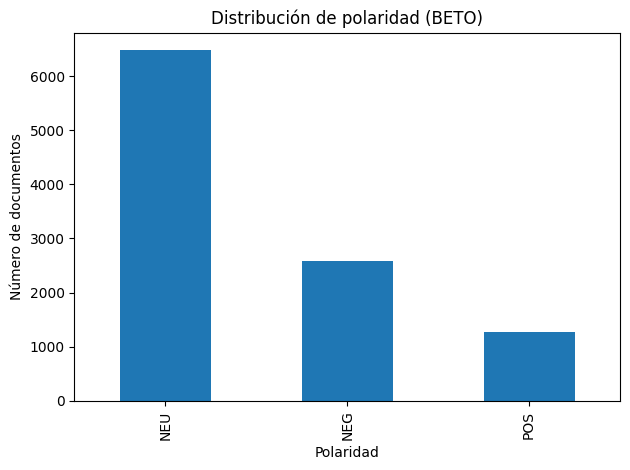

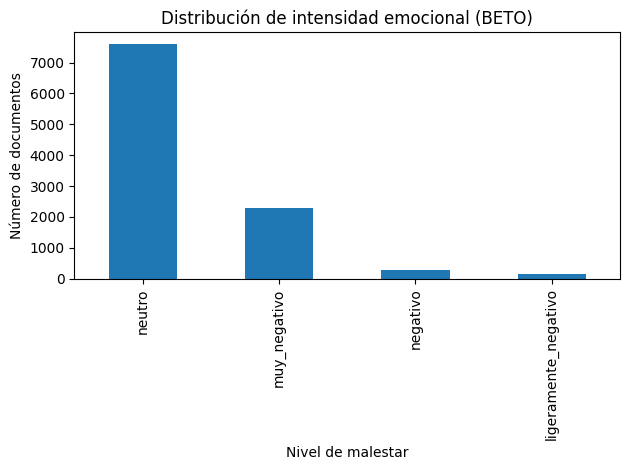

In [ ]:
import matplotlib.pyplot as plt

counts_sent = df["beto_sentiment_label"].value_counts()
counts_emotion = df["beto_emotion_bucket"].value_counts()

plt.figure()
counts_sent.plot(kind="bar")
plt.title("Distribución de polaridad (BETO)")
plt.xlabel("Polaridad")
plt.ylabel("Número de documentos")
plt.tight_layout()
plt.savefig("../figures/distribucion_polaridad_beto.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure()
counts_emotion.plot(kind="bar")
plt.title("Distribución de intensidad emocional (BETO)")
plt.xlabel("Nivel de malestar")
plt.ylabel("Número de documentos")
plt.tight_layout()
plt.savefig("../figures/distribucion_intensidad_emocional_beto.png", dpi=150, bbox_inches="tight")
plt.show()

El análisis conjunto de temática y polaridad revela que la mayoría de las quejas presentan un tono predominantemente neutro, lo que confirma el carácter informativo y administrativo del canal de participación ciudadana. No obstante, se identifican diferencias relevantes entre áreas, con una mayor proporción de mensajes negativos en temáticas directamente relacionadas con la calidad de vida cotidiana, como el ruido nocturno, la limpieza urbana, el aparcamiento y el transporte público. Estas áreas concentran un mayor nivel de malestar ciudadano, lo que sugiere una mayor sensibilidad social y potencial de conflicto.

Por el contrario, ámbitos como parques y zonas verdes, cultura y patrimonio o instalaciones deportivas muestran una presencia relativamente mayor de mensajes positivos, asociados principalmente a agradecimientos tras actuaciones municipales, lo que refleja una percepción más favorable de las intervenciones en estos dominios.

Estos resultados evidencian que el volumen de incidencias no es suficiente para caracterizar la naturaleza de los problemas reportados, y que la señal emocional aporta información complementaria clave. En consecuencia, la combinación de información temática y de sentimiento resulta necesaria tanto para una priorización más realista de las incidencias como para la adaptación del tono de respuesta del agente conversacional, justificando la integración de ambos componentes en el diseño del sistema propuesto.

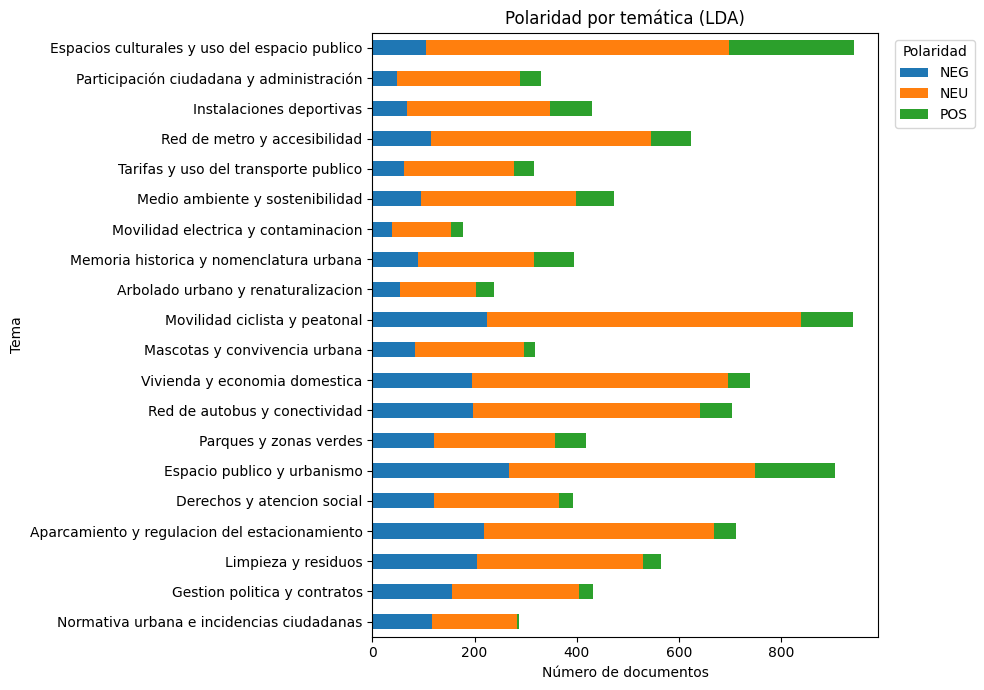

In [ ]:
# 1) tabla de conteos: tema x polaridad
ct = pd.crosstab(df["tema_lda_nombre"], df["beto_sentiment_label"])

for c in ["NEG", "NEU", "POS"]:
    if c not in ct.columns:
        ct[c] = 0

ct = ct[["NEG", "NEU", "POS"]]

# 2) orden por porcentaje NEG (no por volumen)
neg_share = ct["NEG"] / ct.sum(axis=1)
ct = ct.loc[neg_share.sort_values(ascending=False).index]

# 3) si hay demasiados temas
TOP_N = 20 # son todos en lda
ct_plot = ct.head(TOP_N)

# 4) plot horizontal apilado
ax = ct_plot.plot(kind="barh", stacked=True, figsize=(10, 7))
ax.set_title("Polaridad por temática (LDA)")
ax.set_xlabel("Número de documentos")
ax.set_ylabel("Tema")
ax.legend(title="Polaridad", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../figures/polaridad_por_tematica_lda.png", dpi=150, bbox_inches="tight")
plt.show()


**Generación de embeddings contextuales a nivel de documento para representación del sentimiento obtenido**

Con el objetivo de analizar la estructura semántica global del corpus y visualizar la relación entre documentos, se generan embeddings contextuales por documento mediante un modelo de Sentence Transformers. A diferencia de representaciones basadas en conteo (BoW, TF-IDF) o en embeddings estáticos (Word2Vec), estos modelos producen una representación densa del significado completo de cada texto, optimizada para tareas de similitud semántica.

Se emplea el modelo paraphrase-multilingual-MiniLM-L12-v2, que ofrece:

* compatibilidad multilingüe (incluyendo español),

* buena calidad semántica,

* y un coste computacional moderado, adecuado para procesar miles de documentos.

Los embeddings se calculan a partir del campo summary, que conserva la estructura lingüística natural del mensaje, permitiendo al modelo capturar relaciones semánticas más ricas que con texto fuertemente normalizado.

In [11]:
import warnings
warnings.filterwarnings("ignore")
from sentence_transformers import SentenceTransformer
import numpy as np

text_col = "documento"  # ← corrige al nombre real de tu columna
texts = df[text_col].fillna("").astype(str).tolist()

model_name = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
emb_model = SentenceTransformer(model_name)

embeddings = emb_model.encode(
    texts,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)

print(embeddings.shape)  # (n_docs, 384)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/162 [00:00<?, ?it/s]

(10328, 384)


In [12]:
import os
os.makedirs("../artefactos", exist_ok=True)
np.save("../artefactos/embeddings.npy", embeddings)
print("Embeddings guardados en ../artefactos/embeddings.npy")

Embeddings guardados en ../artefactos/embeddings.npy


In [ ]:
#import numpy as np

#embeddings = np.load("embeddings.npy")
#print(embeddings.shape)

(10242, 384)


Dado que los embeddings generados por el modelo de Sentence Transformers tienen alta dimensionalidad (384 dimensiones), se aplica una técnica de reducción de dimensionalidad para proyectar los documentos en un espacio bidimensional que permita su visualización.

Se utiliza UMAP (Uniform Manifold Approximation and Projection), una técnica no lineal que preserva tanto la estructura local como global del espacio semántico, siendo especialmente adecuada para la exploración visual de embeddings de texto.

* Los parámetros se seleccionan para equilibrar:

* la preservación de vecindades semánticas (n_neighbors),

* la compactación de los clusters (min_dist),

* y la similitud coseno como métrica, coherente con la normalización previa de los embeddings.

In [13]:
import umap 
import numpy as np

reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

emb_2d = reducer.fit_transform(embeddings)
emb_2d.shape  # (n_docs, 2)

(10328, 2)

Una vez proyectados los documentos en dos dimensiones mediante UMAP, se visualiza el espacio semántico coloreando cada punto según la polaridad estimada por BETO. Esta representación permite analizar si existen regiones del espacio asociadas a distintos tipos de carga emocional y evaluar si el sentimiento se distribuye de forma estructurada en el espacio semántico o de manera más dispersa.

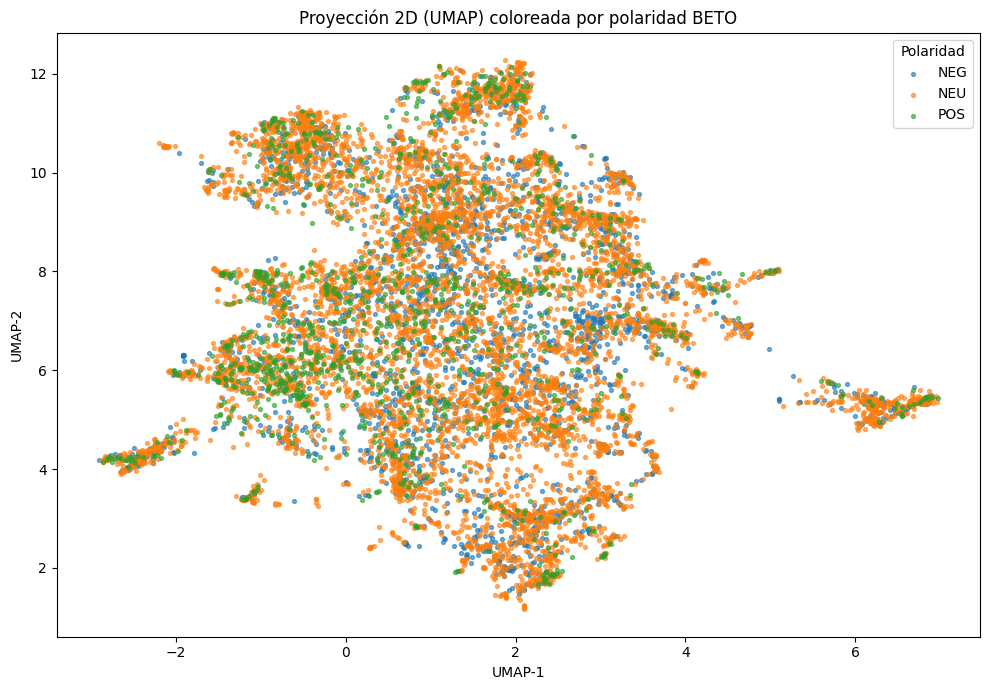

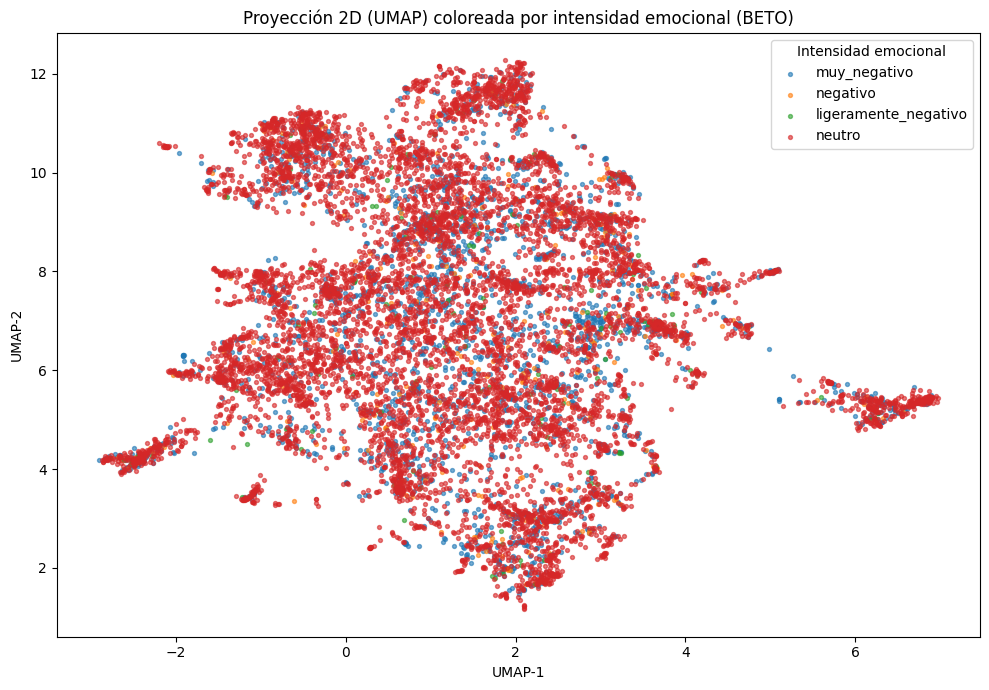

In [14]:
import matplotlib.pyplot as plt

labels = df["beto_sentiment_label"].astype(str)

plt.figure(figsize=(10, 7))
for lab in ["NEG", "NEU", "POS"]:
    mask = labels == lab
    plt.scatter(emb_2d[mask, 0], emb_2d[mask, 1], s=8, alpha=0.6, label=lab)

plt.title("Proyección 2D (UMAP) coloreada por polaridad BETO")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend(title="Polaridad")
plt.tight_layout()
plt.show()

labels = df["beto_emotion_bucket"].astype(str)

order = ["muy_negativo", "negativo", "ligeramente_negativo", "neutro"]

plt.figure(figsize=(10, 7))
for lab in order:
    mask = labels == lab
    plt.scatter(emb_2d[mask, 0], emb_2d[mask, 1], s=8, alpha=0.6, label=lab)

plt.title("Proyección 2D (UMAP) coloreada por intensidad emocional (BETO)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend(title="Intensidad emocional")
plt.tight_layout()
plt.show()



La proyección bidimensional de los embeddings muestra agrupamientos de documentos según su similitud semántica, es decir, en función del contenido temático y del tipo de problema descrito. Estos agrupamientos reflejan que los textos tratan sobre cuestiones similares (por ejemplo, transporte, limpieza, parques, etc.), independientemente del tono emocional con el que se expresen.

La mezcla de mensajes positivos, negativos y neutros dentro de las mismas regiones del espacio indica que la polaridad no define por sí sola el contenido semántico del mensaje, sino que actúa como una dimensión transversal: una misma incidencia puede ser formulada de manera neutral, con enfado o incluso con agradecimiento, sin que ello altere sustancialmente el tema del que se habla.

En consecuencia, la polaridad no genera clusters propios claramente separados, sino que se superpone a la estructura semántica del corpus. Este comportamiento valida el uso de los embeddings para capturar similitud de contenido, y refuerza la idea de que el sentimiento debe considerarse como una señal adicional para la gestión de la interacción (tono del agente, detección de conflicto), pero no como criterio principal para agrupar o clasificar las incidencias.

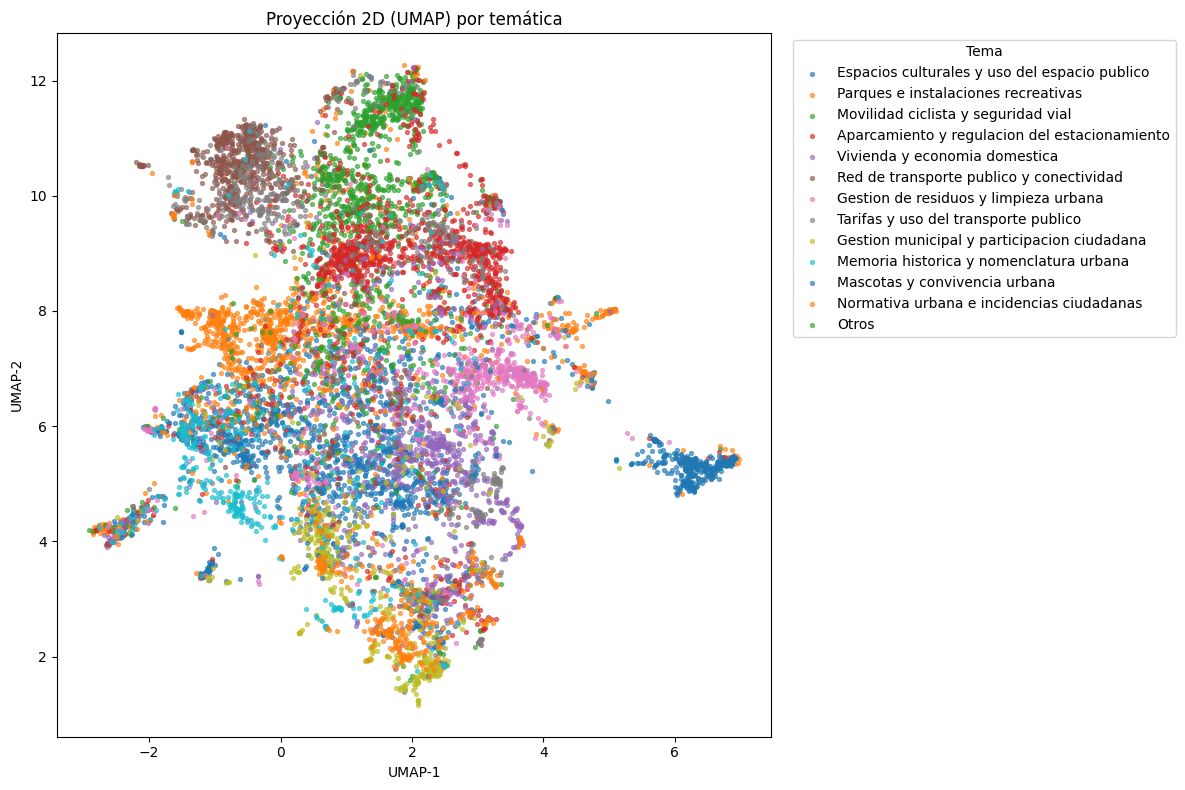

In [15]:
import matplotlib.pyplot as plt

topic_col = "tema_nombre_nmf"      # alternativa: "tema_nombre_nmf"
topics = df[topic_col].astype(str)

# Para que sea legible, muestra solo los TOP_N temas más frecuentes y agrupa el resto en "Otros"
TOP_N = 12
top_topics = topics.value_counts().head(TOP_N).index
topics_plot = topics.where(topics.isin(top_topics), other="Otros")

plt.figure(figsize=(12, 8))
for t in list(top_topics) + ["Otros"]:
    mask = topics_plot == t
    plt.scatter(emb_2d[mask, 0], emb_2d[mask, 1], s=8, alpha=0.6, label=t)

plt.title(f"Proyección 2D (UMAP) por temática")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend(title="Tema", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


La generación de temáticas mediante NMF se realizó a partir de representaciones TF-IDF, es decir, vectores basados en la distribución de términos y su relevancia estadística en el corpus. Este enfoque identifica temas a partir de patrones de coocurrencia léxica y frecuencia de palabras, sin incorporar información contextual profunda.

De forma independiente, en esta fase se han calculado embeddings contextuales a nivel de documento mediante modelos de Sentence Transformers, que capturan relaciones semánticas más ricas basadas en el significado global del texto y no únicamente en la presencia de términos individuales.

El hecho de que, al proyectar estos embeddings mediante UMAP, se observen agrupamientos coherentes que coinciden en gran medida con las temáticas obtenidas previamente por NMF, constituye una validación cruzada del proceso de clasificación temática. Es decir, aunque ambos métodos parten de representaciones muy distintas (TF-IDF frente a embeddings contextuales), ambos capturan una estructura latente similar del corpus.

Este resultado refuerza la consistencia de la clasificación temática obtenida con NMF, indicando que los temas no son únicamente artefactos estadísticos del espacio TF-IDF, sino que reflejan también agrupamientos semánticos reales en el espacio de representación contextual.

**Clasificador supervisado clásico: Naive Bayes**

Además del uso de modelos basados en Transformers, se incorpora un clasificador clásico de PLN, Naive Bayes multinomial, ampliamente estudiado en la literatura y trabajado en la parte teórica de la asignatura. Este modelo asume independencia condicional entre términos y modela la probabilidad de una clase dado un documento a partir de la distribución de palabras.

Su inclusión tiene un objetivo exclusivamente metodológico y comparativo, no operativo dentro del sistema final. En concreto, permite:

* disponer de un baseline interpretable basado en frecuencias léxicas,

* contrastar enfoques clásicos frente a representaciones contextuales profundas,

* y analizar las limitaciones estructurales de modelos que no incorporan información de contexto.

El clasificador se entrena utilizando representaciones TF-IDF del texto preprocesado, coherentes con los modelos de topic modeling aplicados previamente. Dado que el corpus municipal no dispone de etiquetas manuales de sentimiento, se emplea un esquema de pseudo-etiquetado basado en BETO, seleccionando únicamente ejemplos con alta confianza para aproximar un conjunto de entrenamiento supervisado.

Es importante destacar que este procedimiento no pretende generar nuevas etiquetas de sentimiento para el conjunto de datos completo, ni sustituir las predicciones obtenidas con BETO. Utilizar un modelo entrenado con pseudo-etiquetas para reetiquetar el mismo corpus no aportaría información adicional y podría introducir sesgos circulares. Por este motivo, las columnas finales de sentimiento utilizadas por el agente corresponden exclusivamente a las predicciones del modelo BETO preentrenado.

El modelo Naive Bayes se utiliza, por tanto, como herramienta de análisis y validación teórica, permitiendo observar empíricamente cómo los enfoques basados en frecuencia de términos presentan dificultades para capturar matices emocionales y contexto discursivo en quejas ciudadanas reales, especialmente en subconjuntos sensibles como las incidencias con indicadores de riesgo (risk_flag).

Se definen los parámetros básicos del experimento con Naive Bayes: se selecciona la columna de texto de entrada (texto_proc_lema, ya preprocesada y adecuada para modelos léxicos), la columna temática asociada (tema_lda_nombre, útil para análisis posteriores por tema) y un umbral de confianza muy alto (CONF_TH=0.99) para construir pseudo-etiquetas a partir de BETO únicamente cuando la predicción es extremadamente segura. Esto permite generar un subconjunto de entrenamiento con menor ruido para evaluar el baseline clásico sin introducir demasiada incertidumbre en las etiquetas.

In [16]:
# 1) Configuración
TEXT_COL = "texto_proc_lema"   #  el procesado
TOPIC_COL = "tema_lda_nombre"  
CONF_TH = 0.99               # umbral de confianza BETO para pseudo-etiquetar

Se implementa un detector heurístico de incidencias potencialmente relacionadas con riesgo o seguridad, basado en la presencia de palabras clave asociadas a peligros físicos (accidentes, caídas, incendios, falta de iluminación, etc.). Mediante expresiones regulares se identifica si el texto contiene alguno de estos términos y se genera una variable binaria (risk_flag) que marca los mensajes con posibles implicaciones de seguridad. Esta señal no se utiliza para entrenar el modelo de sentimiento, sino para permitir análisis específicos sobre subconjuntos sensibles del corpus y para su futura integración en el módulo de priorización de incidencias.

In [17]:
# 2) Detector simple de "riesgo/seguridad" -> Útil para crear subset y analizar casos sensibles
import re

RISK_WORDS = [
    "peligros", "riesgo", "accident", "atropell", "caid", "caer", "resbal",
    "herid", "urgente", "emergenc", "fuego", "incend", "robo", "agresion",
    "oscuro", "sin luz", "farola", "semaforo", "cruce", "bache", "socavon"
]

risk_pattern = re.compile("|".join(map(re.escape, RISK_WORDS)), flags=re.IGNORECASE)

def risk_flag(text: str) -> int:
    text = "" if pd.isna(text) else str(text)
    return int(bool(risk_pattern.search(text)))

# Crea columna de riesgo sobre texto "natural"
risk_source_col = "summary" if "summary" in df.columns else TEXT_COL
df["risk_flag"] = df[risk_source_col].astype(str).apply(risk_flag)

Se construye un conjunto de entrenamiento supervisado mediante pseudo-etiquetado, utilizando las predicciones de BETO únicamente cuando la probabilidad asociada a una clase supera un umbral de confianza muy alto. Para cada documento se selecciona la etiqueta de sentimiento (NEG, NEU o POS) solo si la puntuación correspondiente excede dicho umbral, descartando el resto de ejemplos para evitar introducir ruido. De este modo se obtiene un subconjunto reducido pero más fiable del corpus, que se emplea exclusivamente para entrenar y evaluar el baseline Naive Bayes, sin modificar las etiquetas finales de sentimiento del dataset completo.

In [18]:
import numpy as np
# 3) Pseudo-etiquetado usando BETO (alta confianza)  -> Genera y_nb (labels) para entrenar NB

def pseudo_label_beto(row, th=CONF_TH):
    neg = row.get("beto_neg_score", np.nan)
    neu = row.get("beto_neu_score", np.nan)
    pos = row.get("beto_pos_score", np.nan)
    if pd.isna(neg) or pd.isna(neu) or pd.isna(pos):
        return None
    if neg >= th:
        return "NEG"
    if pos >= th:
        return "POS"
    if neu >= th:
        return "NEU"
    return None

df["nb_pseudo_label"] = df.apply(pseudo_label_beto, axis=1) # se genera la variable que luego se elimina

df_nb = df.dropna(subset=["nb_pseudo_label"]).copy() # solo ejemplos de alta confianza
print("Ejemplos pseudo-etiquetados (alta confianza):", len(df_nb))
print(df_nb["nb_pseudo_label"].value_counts())

Ejemplos pseudo-etiquetados (alta confianza): 4512
nb_pseudo_label
NEU    2569
NEG    1530
POS     413
Name: count, dtype: int64


Este resultado muestra que, aplicando un umbral de confianza elevado, se obtiene un subconjunto de 4.473 documentos pseudo-etiquetados para el entrenamiento del clasificador clásico. La distribución de clases es claramente desequilibrada, con predominio de mensajes neutros, seguidos de negativos y una proporción menor de positivos, lo que refleja la naturaleza del dominio: la mayoría de las aportaciones ciudadanas consisten en reportes informativos o quejas, mientras que los mensajes de agradecimiento son menos frecuentes. Este desbalance es relevante para interpretar posteriormente el rendimiento del modelo, especialmente en la detección de la clase positiva.

El subconjunto pseudo-etiquetado se divide en conjuntos de entrenamiento y validación. A continuación, el vectorizador TF-IDF se ajusta únicamente sobre el conjunto de entrenamiento y se aplica posteriormente al de validación, evitando así fuga de información y garantizando una evaluación supervisada adecuada.

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X_text = df_nb[TEXT_COL].fillna("").astype(str)
y = df_nb["nb_pseudo_label"].astype(str).values

X_text_tr, X_text_va, y_tr, y_va = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = TfidfVectorizer(max_features=30000, ngram_range=(1,2), min_df=5)

X_tr = vectorizer.fit_transform(X_text_tr)   # fit SOLO en train
X_va = vectorizer.transform(X_text_va)       # transform en valid

En este paso se entrena el clasificador Multinomial Naive Bayes sobre el conjunto de entrenamiento y se evalúa su rendimiento en el conjunto de validación. Las métricas de precisión, recall y F1 por clase, junto con la matriz de confusión, permiten analizar el comportamiento del modelo en cada categoría de sentimiento y comparar sus limitaciones frente al enfoque basado en Transformers.

In [20]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix

nb = MultinomialNB(alpha=0.5)
nb.fit(X_tr, y_tr)

pred = nb.predict(X_va)

print("\n=== Evaluación Naive Bayes (validación) ===")
print(classification_report(y_va, pred, digits=3))
print("Matriz de confusión (orden: NEG, NEU, POS):\n", confusion_matrix(y_va, pred, labels=["NEG","NEU","POS"]))



=== Evaluación Naive Bayes (validación) ===
              precision    recall  f1-score   support

         NEG      0.568     0.288     0.382       306
         NEU      0.614     0.891     0.727       514
         POS      1.000     0.024     0.047        83

    accuracy                          0.607       903
   macro avg      0.727     0.401     0.385       903
weighted avg      0.634     0.607     0.548       903

Matriz de confusión (orden: NEG, NEU, POS):
 [[ 88 218   0]
 [ 56 458   0]
 [ 11  70   2]]


El clasificador Naive Bayes entrenado sobre datos pseudo-etiquetados presenta un fuerte sesgo hacia la clase neutra, con un recall elevado para NEU pero un rendimiento muy bajo en la detección de mensajes negativos y positivos. La mayoría de las quejas con carga emocional se clasifican erróneamente como reportes neutrales, y los mensajes de agradecimiento apenas se detectan.

Este comportamiento es coherente con las limitaciones teóricas del modelo: al basarse exclusivamente en frecuencias léxicas e independencia condicional de términos, no captura el contexto ni la intención comunicativa, que resultan determinantes en el lenguaje de incidencias ciudadanas. Estos resultados refuerzan la elección de BETO como fuente principal de señal emocional en el sistema final.